# BDT Analysis Pipeline: B0 -> D* tau nu (tau -> 3pi nu)

This notebook builds a signal/background classifier using:
- **Signal MC** (`sigB0_v2_part.root`): only candidates with `sigissig == 1`
  are treated as genuine signal; all other candidates in this file (including
  mis-reconstructed combinatorics within signal-generated events) are treated
  as background, same as the dedicated background samples.
- **Background MC** (`ccB0`, `chB0`, `mixB0`): continuum and generic B-decay
  background, subsampled for faster iteration during development.

Pipeline steps:
1. Load and label data (signal vs. background)
2. Pre-cuts (tag-side photon multiplicity, energy resolution, tag energy)
3. Feature engineering (delta_M, M_3pi, CMS angles, triple product, M12, M23, M31)
4. BDT training and evaluation
5. Signal extraction fit

---

## Physics Motivation

We study B0 → D*- τ+ ντ decays where the τ+ is reconstructed in the τ+ → π+ π- π+ ν̄τ mode. This decay is a sensitive probe for New Physics, as the Standard Model predicts zero transverse tau polarization.

---

## Key Features

### 1. Delta M
`delta_M = M(D*) - M(D0)`

The mass difference between the D* and D0 mesons. This is a key variable for identifying D* decays, as the mass splitting is small (~145 MeV) and well-measured.

---

### 2. M_3pi (Invariant Mass of 3 Pions)
`M_3pi = sqrt(E_cms^2 - p_x^2 - p_y^2 - p_z^2)`

The invariant mass of the visible tau-daughter system (3 charged pions), computed directly from the summed 4-vector of the three pions in the CMS frame.

---



### 4. Triple Product (T-odd Observable)

The triple product is constructed using unit vectors for all three components:

$$T = (\hat{p}_{D^*} \times \hat{r}_{\tau}) \cdot \hat{p}_{3\pi}$$

**Why unit vectors?**
- The triple product becomes purely angular and dimensionless
- Bounded in the range `[-1, 1]`
- Avoids issues with energy/momentum scale differences

**Interpretation:**
- `T > 0`: 3 pions fly above the decay plane
- `T < 0`: 3 pions fly below the decay plane
- The asymmetry `A_T = (N_+ - N_-) / (N_+ + N_-)` is proportional to transverse tau polarization `P_T`

This is a **T-odd** observable, making it sensitive to time-reversal violation. Since the Standard Model predicts `P_T = 0`, any non-zero measurement would signal New Physics.

---

### 5. M_pipi_12, M_pipi_13, M_pipi_23 (Pion Pair Masses)

The invariant masses of the three possible ππ pair combinations from the τ → 3π decay:

$$M_{ij} = \sqrt{(E_i + E_j)^2 - (\vec{p}_i + \vec{p}_j)^2}$$

Where `i, j ∈ {1, 2, 3}` are the three pions from the tau decay, with 4-vectors reconstructed from the lab frame.

These variables are sensitive to the τ decay dynamics and the intermediate resonances (e.g., ρ(770)) in the τ → 3πν decay. The two opposite-sign pion pairs will form the ρ resonance peak, while the same-sign pair will have a different mass distribution.

---

### 6. CMS Polar Angle Cosines

$$\cos\theta_{D^0} = \frac{p_{z}^{D^0}}{|\vec{p}_{D^0}|}$$

$$\cos\theta_{D^*} = \frac{p_{z}^{D^*}}{|\vec{p}_{D^*}|}$$

The cosine of the polar angle in the center-of-mass frame for D0 and D*. These are used for continuum suppression, as signal events from B decays have a different angular distribution than continuum background.

---

### 7. Additional Variables

- **mm2**: Missing mass squared
- **tagnph**: Number of photons on tag side (pre-cut: `< 9`)
- **cosTBTO**: Thrust angle between B and tag sides
- **d0cmvxp, taucmvx**: Vertex-fit related variables
- **d0chi2, tauchi2**: Chi-square of vertex fits
- **eresdiff**: Energy resolution difference (pre-cut: `< 0.6`)
- **tagde**: Tag-side energy (pre-cut: `< 0.1`)




In [1]:
# =============================================================================
# BELLE II B0 → D*π ANALYSIS WITH BDT OPTIMIZATION
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot as up
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc
from scipy.optimize import curve_fit
from scipy.stats import argus, norm, crystalball, ks_2samp
import mplhep as hep
import warnings
warnings.filterwarnings('ignore')

plt.style.use(hep.style.LHCb2)

# =========================================================================
# PHYSICAL CONSTANTS
# =========================================================================
M_PI = 0.13957039
M_RHO = 0.7752
D0_MASS = 1.86484

# PART 1: DATA LOADING, PRE-CUTS, AND LABELING

## Load Signal and Background Data

Signal data is loaded from a single ROOT file containing B0 → D*- τ+ ντ Monte Carlo events.

Background data is loaded from three separate files:
- **ccB0**: Continuum background (e+e- → qq̄)
- **chB0**: Charged B decays
- **mixB0**: Mixed B decays (B0 and B̄0 combinations)

In [2]:
# =============================================================================
# PART 1: DATA LOADING, PRE-CUTS, AND LABELING
# =============================================================================
print("=" * 60)
print("STEP 1: DATA LOADING")
print("=" * 60)

# Load signal data
df_sig = up.open("/net/pr2/projects/plgrid/plggbelle2ml/ppss_2026/samples_v2/sigB0_v2_part.root")["B0"].arrays(library="pd")

# Load background data from multiple files
path_base = Path("/net/pr2/projects/plgrid/plggbelle2ml/ppss_2026/samples_v2")
archivos = [
    f"{path_base / 'ccB0_v2_part.root'}:B0",
    f"{path_base / 'chB0_v2_part.root'}:B0",
    f"{path_base / 'mixB0_v2_part.root'}:B0",
]
df_bk = up.concatenate(archivos, library="pd")

print(f"Signal (raw):     {len(df_sig)}")
print(f"Background (raw): {len(df_bk)}")

# -----------------------------------------------------------------------
# Subsample background for faster development iteration. Increase
# FRAC_BK (up to 1.0) for the final, full-statistics run.
# -----------------------------------------------------------------------
FRAC_BK = 0.4
df_bk = df_bk.sample(frac=FRAC_BK, random_state=42).reset_index(drop=True)
print(f"Background after subsampling ({FRAC_BK*100:.0f}%): {len(df_bk)}")



STEP 1: DATA LOADING
Signal (raw):     1027745
Background (raw): 1954028
Background after subsampling (40%): 781611


# PART 2: COMBINE ALL SAMPLES

## Concatenate Signal and Background

After loading the individual samples, they are concatenated into a single combined dataframe. This ensures that all subsequent operations (pre-cuts, feature engineering, BDT training) are applied uniformly to both signal and background.

In [3]:


# =============================================================================
# STEP 2: CONCATENATE ALL FILES FIRST, into a single combined dataframe
# =============================================================================
print("\n" + "=" * 60)
print("STEP 2: COMBINE ALL SAMPLES")
print("=" * 60)

df_all = pd.concat([df_sig, df_bk], ignore_index=True)
print(f"Combined (raw, before cuts): {len(df_all)}")

# sanity check: sigissig must exist in the combined sample
if "sigissig" not in df_all.columns:
    raise KeyError("sigissig column missing after concat - check that both "
                    "df_sig and df_bk contain this branch before combining.")
print(f"NaN in sigissig: {df_all['sigissig'].isna().sum()} / {len(df_all)}")



STEP 2: COMBINE ALL SAMPLES
Combined (raw, before cuts): 1809356
NaN in sigissig: 148808 / 1809356


# PART 3: FEATURE ENGINEERING

This section constructs the key features used for BDT training. All features are derived from reconstructed quantities and are designed to maximize discrimination between signal and background.

---

## 1. Delta M

$$\Delta M = M(D^*) - M(D^0)$$

The mass difference between the D* and D0 mesons. This is a key variable for identifying D* decays, as the mass splitting is small (~145 MeV) and well-measured.

---

## 2. M_3pi (Invariant Mass of 3 Pions)

$$M_{3\pi} = \sqrt{E_{3\pi}^{2} - |\vec{p}_{3\pi}|^{2}}$$

The invariant mass of the visible tau-daughter system (3 charged pions), computed directly from the summed 4-vector in the CMS frame.

---

## 3. CMS Polar Angle Cosines (Continuum Suppression)

$$\cos\theta_{D^0} = \frac{p_z^{D^0}}{|\vec{p}_{D^0}|}$$

$$\cos\theta_{D^*} = \frac{p_z^{D^*}}{|\vec{p}_{D^*}|}$$

The cosine of the polar angle in the center-of-mass frame for D0 and D*. These variables are used for continuum suppression, as signal events from B decays have a different angular distribution than continuum background.

---

## 4. Triple Product (T-odd Observable)

$$T = (\hat{p}_{D^*} \times \hat{r}_{\tau}) \cdot \hat{p}_{3\pi}$$

The triple product is constructed using **unit vectors** for all three components, making it purely angular and dimensionless, bounded in the range `[-1, 1]`.

Where:
- $\hat{p}_{D^*}$ = D* momentum unit vector in CMS frame
- $\hat{r}_{\tau}$ = τ direction unit vector from interaction point (IP) to tau vertex
- $\hat{p}_{3\pi}$ = 3π system momentum unit vector in CMS frame

**Interpretation:**
- `T > 0`: 3 pions fly above the decay plane
- `T < 0`: 3 pions fly below the decay plane

The asymmetry is defined as:

$$A_T = \frac{N_+ - N_-}{N_+ + N_-}$$

where $N_+$ and $N_-$ are the number of events with positive and negative triple product. This asymmetry is proportional to the transverse tau polarization $P_T$:

$$A_T \propto P_T$$

This is a **T-odd** observable, making it sensitive to time-reversal violation. Since the Standard Model predicts $P_T = 0$, any non-zero measurement would signal New Physics.

---

## 5. Pion Pair Masses (M_pipi)

$$M_{ij} = \sqrt{(E_i + E_j)^2 - (\vec{p}_i + \vec{p}_j)^2}$$

The invariant masses of the three possible ππ pair combinations from the τ → 3π decay, where `i, j ∈ {1, 2, 3}` are the three pions from the tau decay, with 4-vectors reconstructed from the lab frame.

These variables are sensitive to the τ decay dynamics and intermediate resonances (e.g., ρ(770)) in the τ → 3πν decay. The two opposite-sign pion pairs will form the ρ resonance peak, while the same-sign pair will have a different mass distribution.

---


## Summary of Engineered Features

| Feature | Description | Units |
|---------|-------------|-------|
| `delta_M` | $M(D^*) - M(D^0)$ | GeV |
| `M_3pi` | Invariant mass of 3 pions | GeV |
| `d0_cosTheta_cms` | CMS polar angle cosine for D0 | dimensionless |
| `dstar_cosTheta_cms` | CMS polar angle cosine for D* | dimensionless |
| `triple_product_reco` | T-odd triple product | dimensionless |
| `M_pipi_12` | Invariant mass of π1π2 pair | GeV |
| `M_pipi_13` | Invariant mass of π1π3 pair | GeV |
| `M_pipi_23` | Invariant mass of π2π3 pair | GeV |



In [4]:
print("="*60)
print("STEP 3: FEATURE ENGINEERING")
print("="*60)

# -----------------------------------------------------------------------
# delta_M = M(D*) - M(D0)
# -----------------------------------------------------------------------
df_all["delta_M"] = df_all["dstm"] - df_all["d0m"]

# -----------------------------------------------------------------------
# M_3pi: invariant mass of the visible tau-daughter (3pi) system,
# computed directly from the summed 4-vector (equivalent to taum, kept
# explicit here for clarity/consistency with the rest of the analysis)
# -----------------------------------------------------------------------
df_all["M_3pi"] = np.sqrt(np.clip(
    df_all["tauecms"]**2
    - df_all["taupxcms"]**2 - df_all["taupycms"]**2 - df_all["taupzcms"]**2,
    0, None
))

# -----------------------------------------------------------------------
# CMS-frame polar angle cosines (continuum suppression variables)
# -----------------------------------------------------------------------
df_all["d0_cosTheta_cms"] = df_all["d0pzcms"] / np.sqrt(
    df_all["d0pxcms"]**2 + df_all["d0pycms"]**2 + df_all["d0pzcms"]**2 + 1e-10)
df_all["dstar_cosTheta_cms"] = df_all["dstpzcms"] / np.sqrt(
    df_all["dstpxcms"]**2 + df_all["dstpycms"]**2 + df_all["dstpzcms"]**2 + 1e-10)

# -----------------------------------------------------------------------
# Triple product using UNIT VECTORS for all three components:
#   T = (p_hat_D* x tau_hat) . p_hat_3pi
# Every vector normalized to unit length before use, so T is purely
# angular/dimensionless (bounded in [-1, 1]), not GeV^2.
# -----------------------------------------------------------------------
tau_dir_x = df_all["taux"] - df_all["IPX"]
tau_dir_y = df_all["tauy"] - df_all["IPY"]
tau_dir_z = df_all["tauz"] - df_all["IPZ"]
tau_dir_mag = np.sqrt(tau_dir_x**2 + tau_dir_y**2 + tau_dir_z**2 )
tau_hat_x = tau_dir_x / tau_dir_mag
tau_hat_y = tau_dir_y / tau_dir_mag
tau_hat_z = tau_dir_z / tau_dir_mag

Dstar_p_mag = np.sqrt(
    df_all["dstpxcms"]**2 + df_all["dstpycms"]**2 + df_all["dstpzcms"]**2 )
Dstar_hat_x = df_all["dstpxcms"] / Dstar_p_mag
Dstar_hat_y = df_all["dstpycms"] / Dstar_p_mag
Dstar_hat_z = df_all["dstpzcms"] / Dstar_p_mag

pi3_p_mag = np.sqrt(
    df_all["taupxcms"]**2 + df_all["taupycms"]**2 + df_all["taupzcms"]**2 )
pi3_hat_x = df_all["taupxcms"] / pi3_p_mag
pi3_hat_y = df_all["taupycms"] / pi3_p_mag
pi3_hat_z = df_all["taupzcms"] / pi3_p_mag

# cross product: (p_hat_D* x tau_hat)
cross_x = Dstar_hat_y * tau_hat_z - Dstar_hat_z * tau_hat_y
cross_y = Dstar_hat_z * tau_hat_x - Dstar_hat_x * tau_hat_z
cross_z = Dstar_hat_x * tau_hat_y - Dstar_hat_y * tau_hat_x

df_all["triple_product_reco"] = (
    cross_x * pi3_hat_x + cross_y * pi3_hat_y + cross_z * pi3_hat_z
)


# =========================================================================
# STEP 1: Reconstructed pion 4-vectors from df_all (LAB frame)
# =========================================================================
pi_raw = {}
for i in [1, 2, 3]:
    pi_raw[i] = {
        "E":   df_all[f"taupi{i}elab"].to_numpy(),
        "px":  df_all[f"taupi{i}pxlab"].to_numpy(),
        "py":  df_all[f"taupi{i}pylab"].to_numpy(),
        "pz":  df_all[f"taupi{i}pzlab"].to_numpy(),
    }

# =========================================================================
# STEP 2: Compute all three pair invariant mass-squared combinations
# =========================================================================
def inv_mass2_from_dict(pA, pB):
    E = pA["E"] + pB["E"]
    px = pA["px"] + pB["px"]
    py = pA["py"] + pB["py"]
    pz = pA["pz"] + pB["pz"]
    return E**2 - (px**2 + py**2 + pz**2)

# Compute all three possible pair combinations
m2_12 = inv_mass2_from_dict(pi_raw[1], pi_raw[2])
m2_13 = inv_mass2_from_dict(pi_raw[1], pi_raw[3])
m2_23 = inv_mass2_from_dict(pi_raw[2], pi_raw[3])

# Convert to mass
M_12 = np.sqrt(np.clip(m2_12, 0, None))
M_13 = np.sqrt(np.clip(m2_13, 0, None))
M_23 = np.sqrt(np.clip(m2_23, 0, None))

# =========================================================================
# STEP 3: Add columns to df_all
# =========================================================================
df_all["M_pipi_12"] = M_12
df_all["M_pipi_13"] = M_13
df_all["M_pipi_23"] = M_23



STEP 3: FEATURE ENGINEERING


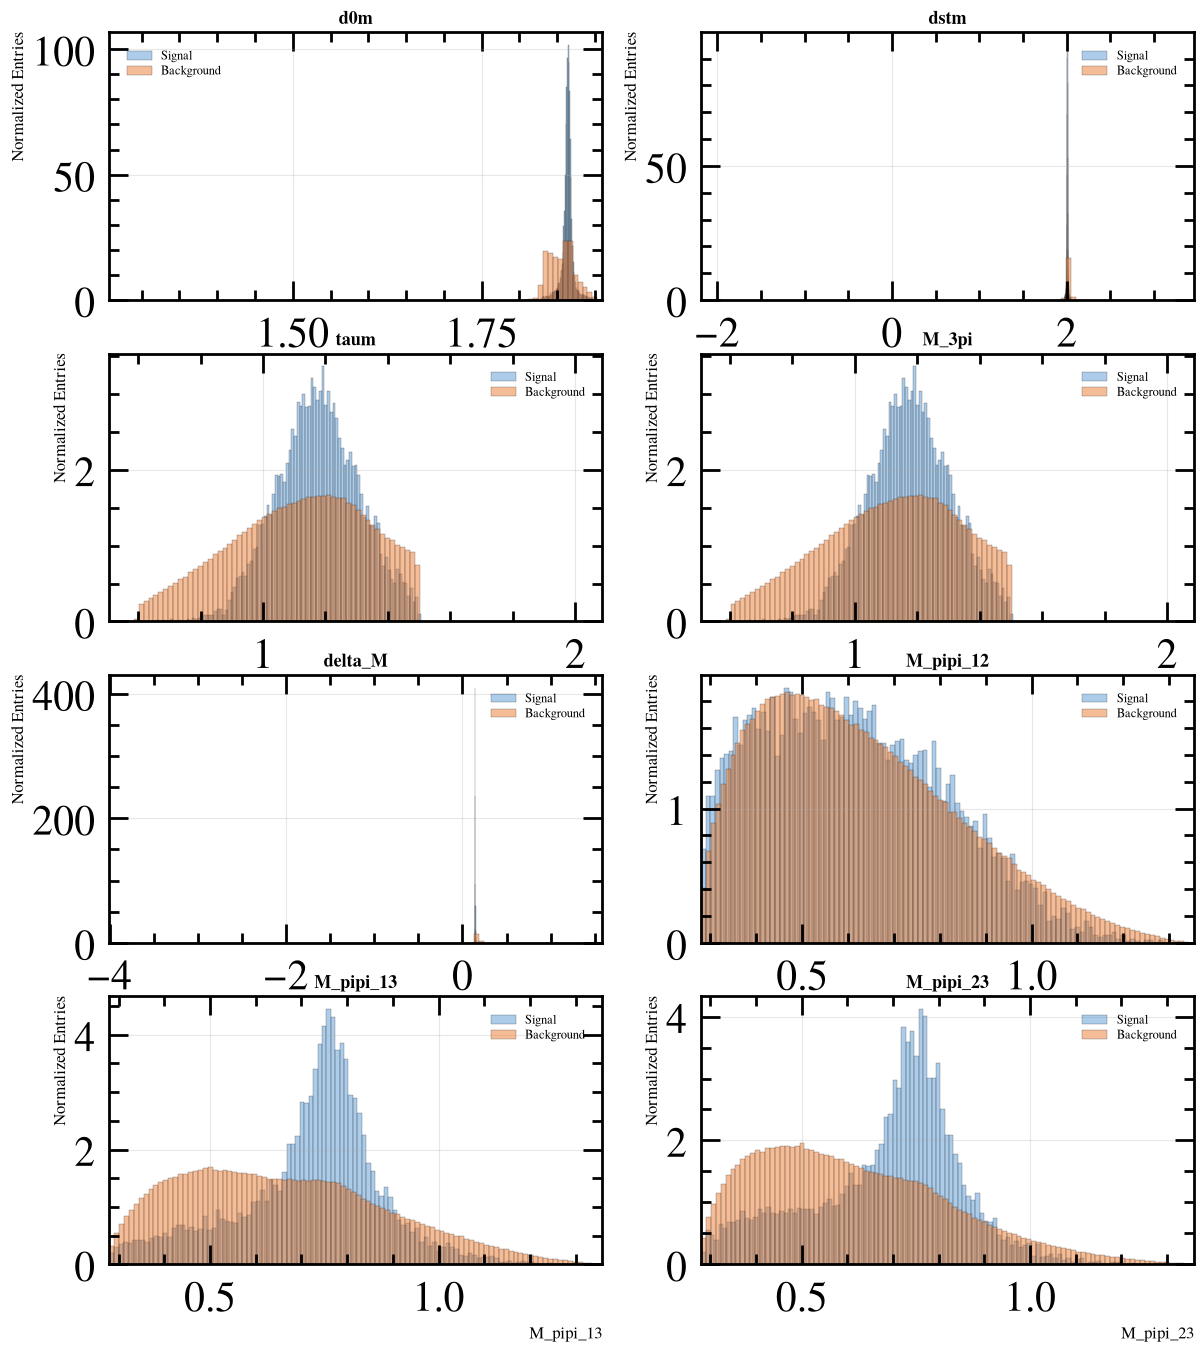

In [5]:
plt.style.use(hep.style.LHCb2)

# List of mass-related features to plot
mass_features = [
    "d0m",           # D0 mass
    "dstm",          # D* mass
    "taum",          # Tau mass (from 3pi)
    "M_3pi",         # Reconstructed 3pi mass
    "delta_M",       # M(D*) - M(D0)
    "M_pipi_12",     # Invariant mass of pion pair 1-2
    "M_pipi_13",     # Invariant mass of pion pair 1-3
    "M_pipi_23",     # Invariant mass of pion pair 2-3
]

n_cols = 2
n_rows = (len(mass_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes]

for idx, feature in enumerate(mass_features):
    ax = axes[idx]
    
    # Signal: sigissig == 1
    signal_vals = df_all.query("sigissig == 1")[feature].dropna()
    ax.hist(signal_vals, bins=100, density=True, alpha=0.5, color='#5B9BD5', 
            edgecolor='black', linewidth=0.3, label='Signal')
    
    # Background: sigissig != 1
    bkg_vals = df_all.query("sigissig != 1")[feature].dropna()
    ax.hist(bkg_vals, bins=100, density=True, alpha=0.5, color='#ED7D31', 
            edgecolor='black', linewidth=0.3, label='Background')
    
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('Normalized Entries', fontsize=12)
    ax.set_title(feature, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    

# PART 4: GENERAL PRE-CUTS AND LABELING

## Pre-Cuts

After feature engineering, a set of general pre-cuts is applied uniformly to all events in the combined dataframe. These cuts remove poorly reconstructed events and improve the signal-to-background ratio before BDT training.

| Cut | Variable | Condition | Purpose |
|-----|----------|-----------|---------|
| Tag photon multiplicity | `tagnph` | `< 9` | Remove events with excessive photons on tag side |
| Energy resolution difference | `eresdiff` | `< 0.6` | Ensure good energy reconstruction |
| Tag-side energy | `tagde` | `< 0.1` | Remove poorly reconstructed tag-side events |
| Delta M | `deltaM` | `< 0.16` | Ensure D* mass difference is within physical range |

All cuts are applied identically to signal and background samples to avoid any bias.

---

## Labeling Strategy

After pre-cuts, the `label` column is created:

| Label | Value | Description |
|-------|-------|-------------|
| Signal | `1` | Events where `sigissig == 1` (truth-matched signal candidates) |
| Background | `0` | Everything else, including: |

- Mis-reconstructed events from signal MC (`sigissig != 1`)
- Dedicated background samples (`ccB0`, `chB0`, `mixB0`)

This unified labeling ensures that all non-signal candidates are treated as background, regardless of their origin.

In [6]:
# =============================================================================
# PART 4: APPLY GENERAL PRE-CUTS to the combined dataframe (one definition,
# applied identically to every source file - no risk of inconsistency)
# =============================================================================
print("\n" + "=" * 60)
print("STEP 3: GENERAL PRE-CUTS")
print("=" * 60)

general_cuts = (
    (df_all["tagnph"] < 9) &
    (df_all["eresdiff"] < 0.6) &
    (df_all["tagde"] < 0.1) &
    (df_all["delta_M"] < 0.16) &
    (df_all["taum"] > 0.9) &
    #(abs(df_sig["d0m"] - D0_MASS) < 0.01) & 
    (df_sig["tagpval"] > 0.002) 
    # Lepton veto
    #(df_sig["tagne"] == 0) &
    #(df_sig["tagnmu"] == 0) 

)

n_before = len(df_all)
df_all = df_all[general_cuts].reset_index(drop=True)
print(f"Combined: {n_before} -> {len(df_all)} ({100*len(df_all)/n_before:.1f}% retained)")

# =============================================================================
# STEP 4: LABEL - signal is sigissig==1 (post cuts), everything else is
# background (combinatorics within signal MC AND generic bkg samples,
# treated uniformly since they're now in the same combined dataframe)
# =============================================================================
print("\n" + "=" * 60)
print("STEP 4: LABELING")
print("=" * 60)

df_all["label"] = (df_all["sigissig"] == 1).astype(int)

n_signal = (df_all["label"] == 1).sum()
n_bkg = (df_all["label"] == 0).sum()
print(f"Signal (sigissig==1):     {n_signal}")
print(f"Background (sigissig!=1): {n_bkg}")
print(f"Signal fraction: {df_all['label'].mean():.4f}")


STEP 3: GENERAL PRE-CUTS
Combined: 1809356 -> 61206 (3.4% retained)

STEP 4: LABELING
Signal (sigissig==1):     2478
Background (sigissig!=1): 58728
Signal fraction: 0.0405


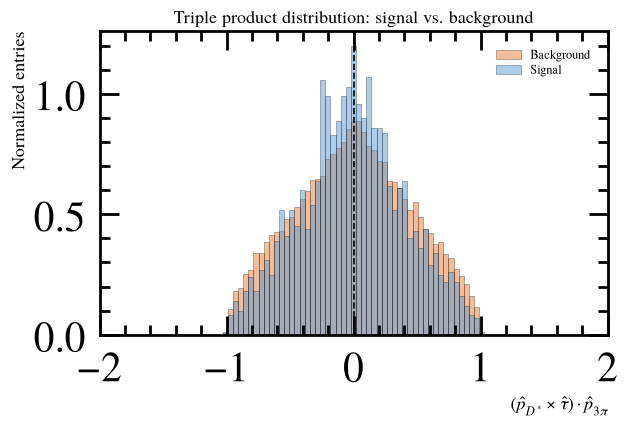

Signal:     N(+)=1212, N(-)=1266, asymmetry=-0.0218
Background: N(+)=29504, N(-)=29224, asymmetry=0.0048


In [7]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))

tp_valid = df_all["triple_product_reco"].dropna()
tp_valid = tp_valid[np.isfinite(tp_valid)]


bins = np.linspace(-2, 2, 100)

sig_mask = df_all.loc[tp_valid.index, "label"] == 1
bkg_mask = df_all.loc[tp_valid.index, "label"] == 0

ax.hist(tp_valid[bkg_mask], bins=bins, alpha=0.5, color="#ED7D31",
        edgecolor="black", linewidth=0.4, label="Background", density=True)
ax.hist(tp_valid[sig_mask], bins=bins, alpha=0.5, color="#5B9BD5",
        edgecolor="black", linewidth=0.4, label="Signal", density=True)

ax.axvline(0, color="black", linestyle="--", linewidth=1.2)
ax.set_xlabel(r"$( \hat{p}_{D^*} \times \hat{\tau} ) \cdot \hat{p}_{3\pi}$", fontsize=13)
ax.set_ylabel("Normalized entries", fontsize=13)
ax.set_title("Triple product distribution: signal vs. background", fontsize=13)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

n_pos_sig = (tp_valid[sig_mask] > 0).sum()
n_neg_sig = (tp_valid[sig_mask] < 0).sum()
n_pos_bkg = (tp_valid[bkg_mask] > 0).sum()
n_neg_bkg = (tp_valid[bkg_mask] < 0).sum()
print(f"Signal:     N(+)={n_pos_sig}, N(-)={n_neg_sig}, "
      f"asymmetry={(n_pos_sig-n_neg_sig)/(n_pos_sig+n_neg_sig):.4f}")
print(f"Background: N(+)={n_pos_bkg}, N(-)={n_neg_bkg}, "
      f"asymmetry={(n_pos_bkg-n_neg_bkg)/(n_pos_bkg+n_neg_bkg):.4f}")

# ρ Resonance in τ → 3πν Decay

## Sanity Mask

Basic quality cuts to ensure D* and D0 masses are within reasonable ranges:

| Variable | Condition | Purpose |
|----------|-----------|---------|
| `dstm` | (1.9, 2.1) GeV | D* mass window |
| `d0m` | (1.7, 2.0) GeV | D0 mass window |

---

## Folded Mass Plot (M_ππ)

All three ππ pair combinations are combined into a single histogram:

- $M_{12} = M(\pi_1\pi_2)$
- $M_{13} = M(\pi_1\pi_3)$
- $M_{23} = M(\pi_2\pi_3)$

**Signal** (blue): Clear peak at the ρ(770) mass (0.775 GeV) from opposite-sign pion pairs  
**Background** (red): distribution with no significant structure

---

## Dalitz Plot (Signal Only)

Signal events projected onto the Dalitz plane:

- $x$-axis: $M^2(\pi_1\pi_2)$
- $y$-axis: $M^2(\pi_1\pi_3)$

The ρ resonance appears as a band/structure in the Dalitz plot, confirming the intermediate ρ(770) state in τ → 3πν decays.



Events passing sanity mask: 61205 / 61206


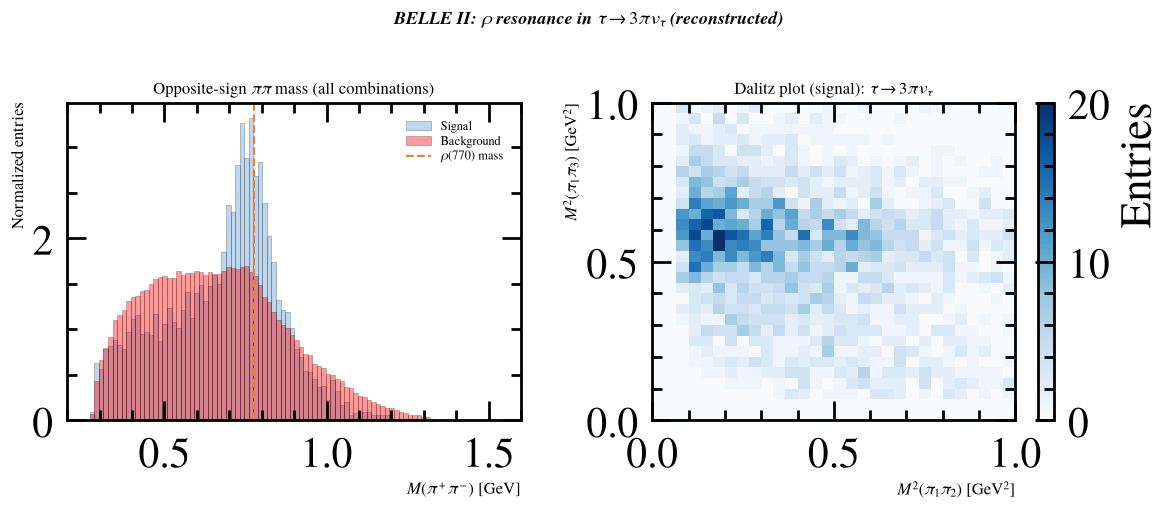

In [8]:

plt.style.use(hep.style.LHCb2)


# =========================================================================
# STEP 4: Sanity mask and plotting
# =========================================================================
df_all["sanity_ok"] = (
    (df_all["dstm"] > 1.9) & (df_all["dstm"] < 2.1) &
    (df_all["d0m"] > 1.7) & (df_all["d0m"] < 2.0)
)

print(f"\nEvents passing sanity mask: {df_all['sanity_ok'].sum()} / {len(df_all)}")

# =========================================================================
# STEP 5: Plotting - use all three combinations
# =========================================================================
query_signal = "sanity_ok == True & label == 1"
query_bkg = "sanity_ok == True & label == 0"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Folded mass plot using all three combinations
ax = axes[0]
df_sig = df_all.query(query_signal)
bkg_df = df_all.query(query_bkg)

# Combine all three pair combinations for signal
sig_folded = pd.concat([
    df_sig["M_pipi_12"],
    df_sig["M_pipi_13"],
    df_sig["M_pipi_23"]
]).dropna()

# Combine all three pair combinations for background
bkg_folded = pd.concat([
    bkg_df["M_pipi_12"],
    bkg_df["M_pipi_13"],
    bkg_df["M_pipi_23"]
]).dropna()

ax.hist(sig_folded, bins=100, range=(0.2, 1.6), color='#5B9BD5',
        edgecolor='black', linewidth=0.4, alpha=0.4, density=True, label='Signal')
ax.hist(bkg_folded, bins=100, range=(0.2, 1.6), color='red',
        edgecolor='black', linewidth=0.4, alpha=0.4, density=True, label='Background')
ax.axvline(M_RHO, color='#ED7D31', linestyle='--', linewidth=1.5, label=r'$\rho(770)$ mass')
ax.set_xlabel(r'$M(\pi^+\pi^-)$ $[\mathrm{GeV}]$', fontsize=12)
ax.set_ylabel('Normalized entries', fontsize=12)
ax.set_title(r'Opposite-sign $\pi\pi$ mass (all combinations)', fontsize=12)
ax.legend(fontsize=9)

# Dalitz plot - using M_12 and M_13
ax = axes[1]
h = ax.hist2d(df_sig["M_pipi_12"]**2, df_sig["M_pipi_13"]**2, bins=30,
              range=[[0, 1], [0, 1]], cmap='Blues')
ax.set_xlabel(r'$M^2(\pi_1\pi_2)$ $[\mathrm{GeV}^2]$', fontsize=12)
ax.set_ylabel(r'$M^2(\pi_1\pi_3)$ $[\mathrm{GeV}^2]$', fontsize=12)
ax.set_title(r'Dalitz plot (signal): $\tau \to 3\pi\nu_\tau$', fontsize=12)
fig.colorbar(h[3], ax=ax, label='Entries')

fig.suptitle(r'BELLE II: $\rho$ resonance in $\tau \to 3\pi\nu_\tau$ (reconstructed)',
             fontsize=13, style='italic', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
print("="*60)
print("STEP 5: FEATURE SELECTION & DATA PREPARATION")
print("="*60)

# prioritize the physically-motivated core variables, then add anything
# else with good data coverage
features = [
    "d0chi2", 
    "d0cmvxp", 
    "tauchi2", 
    #"delta_M",
    "M_pipi_12",
    "M_pipi_23",
    "M_pipi_13",
    "M_3pi",
    "taud", 
    "tausd",
    "tagde", 
    "tagpval", 
    "tagchi2",
    "d0_cosTheta_cms", 
    "dstar_cosTheta_cms",
    "foxWolframR2", 
    "R2", 
    "thrust", 
    "sphericity", 
    "aplanarity",
    #"delta_M", 
    #"d0m", 
    #"dstm", 
    #"taum", 
    "mw2", 
    "mm2",
    "tauecmw", 
    "taupcmw", 
    "hecmw", 
    "hpcmw", 
    "costauhcmw",
    "triple_product_reco",
    "tagnph", 
    "tagnpi", 
    "tagnk", 
    "tagndf",
    "eresdiff", 
    "eres", 
    "eresn",
]

print(f"Using {len(features)} features:")
for f in features:
    print(f"  - {f}")

columns_to_keep = features + ["label"]
data = df_all[columns_to_keep].dropna()

print(f"\nBefore dropna: {len(df_all)}")
print(f"After dropna:  {len(data)}")

if len(data) == 0:
    print("\nERROR: no rows survived dropna. Checking each feature individually:")
    for f in features:
        n_ok = df_all[[f, "label"]].dropna().shape[0]
        print(f"  {f:22s}: {n_ok} rows survive alone")
else:
    X = data[features]
    y = data["label"].astype(int)
    print(f"\nUsable rows: {len(data)}")
    print(f"Signal fraction: {y.mean():.4f}  "
          f"(signal={y.sum()}, background={len(y)-y.sum()})")

STEP 5: FEATURE SELECTION & DATA PREPARATION
Using 34 features:
  - d0chi2
  - d0cmvxp
  - tauchi2
  - M_pipi_12
  - M_pipi_23
  - M_pipi_13
  - M_3pi
  - taud
  - tausd
  - tagde
  - tagpval
  - tagchi2
  - d0_cosTheta_cms
  - dstar_cosTheta_cms
  - foxWolframR2
  - R2
  - thrust
  - sphericity
  - aplanarity
  - mw2
  - mm2
  - tauecmw
  - taupcmw
  - hecmw
  - hpcmw
  - costauhcmw
  - triple_product_reco
  - tagnph
  - tagnpi
  - tagnk
  - tagndf
  - eresdiff
  - eres
  - eresn

Before dropna: 61206
After dropna:  61206

Usable rows: 61206
Signal fraction: 0.0405  (signal=2478, background=58728)


In [10]:
print("="*60)
print("STEP 6: TRAIN/TEST SPLIT & BDT TRAINING")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} ({y_train.mean():.4f} signal)")
print(f"Test:  {len(X_test)} ({y_test.mean():.4f} signal)")

bdt = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2, min_samples_leaf=500),
    n_estimators=500,
    learning_rate=0.1,
    random_state=42
)
bdt.fit(X_train, y_train)

y_score_train = bdt.decision_function(X_train)
y_score_test = bdt.decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test, y_score_test)
roc_auc = auc(fpr, tpr)
print(f"\nTest-set ROC AUC: {roc_auc:.3f}")



STEP 6: TRAIN/TEST SPLIT & BDT TRAINING
Train: 42844 (0.0405 signal)
Test:  18362 (0.0405 signal)

Test-set ROC AUC: 0.826



Train-set ROC AUC: 0.848
Test-set ROC AUC:  0.826

Feature importances:
  M_pipi_13              0.3278  ################
  M_pipi_23              0.2577  ############
  mm2                    0.0678  ###
  d0chi2                 0.0497  ##
  taud                   0.0365  #
  M_pipi_12              0.0322  #
  tagnph                 0.0319  #
  tauecmw                0.0294  #
  M_3pi                  0.0272  #
  tagchi2                0.0223  #
  tauchi2                0.0222  #
  d0cmvxp                0.0190  
  tagnpi                 0.0123  
  costauhcmw             0.0110  
  eresn                  0.0102  
  tagndf                 0.0096  
  tagde                  0.0079  
  aplanarity             0.0059  
  d0_cosTheta_cms        0.0042  
  tagnk                  0.0028  
  R2                     0.0024  
  foxWolframR2           0.0024  
  eresdiff               0.0021  
  sphericity             0.0015  
  taupcmw                0.0010  
  mw2                    0.0010  
  t

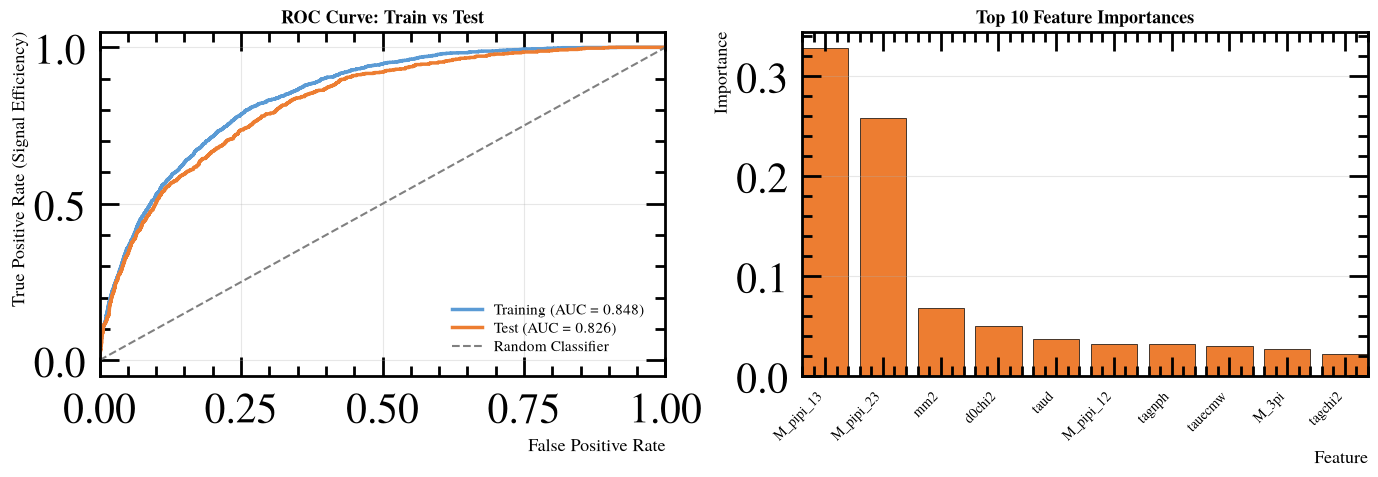

In [11]:
# ROC for train and test
fpr_train, tpr_train, _ = roc_curve(y_train, y_score_train)
fpr_test, tpr_test, _ = roc_curve(y_test, y_score_test)
roc_auc_train = auc(fpr_train, tpr_train)
roc_auc_test = auc(fpr_test, tpr_test)
print(f"\nTrain-set ROC AUC: {roc_auc_train:.3f}")
print(f"Test-set ROC AUC:  {roc_auc_test:.3f}")

print("\nFeature importances:")
for feat, imp in sorted(zip(features, bdt.feature_importances_), key=lambda x: -x[1]):
    bar = "#" * int(imp * 50)
    print(f"  {feat:22s} {imp:.4f}  {bar}")

# =========================================================================
# PLOT: ROC Curve (Train vs Test) and Feature Importances
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve - Train vs Test
ax = axes[0]
ax.plot(fpr_train, tpr_train, color='#5B9BD5', linewidth=2.5, label=f'Training (AUC = {roc_auc_train:.3f})')
ax.plot(fpr_test, tpr_test, color='#ED7D31', linewidth=2.5, label=f'Test (AUC = {roc_auc_test:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate (Signal Efficiency)', fontsize=13)
ax.set_title('ROC Curve: Train vs Test', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

# Feature Importances - Vertical Bars
ax = axes[1]
feat_names = [f[0] for f in sorted(zip(features, bdt.feature_importances_), key=lambda x: -x[1])][:10]
feat_imps = [f[1] for f in sorted(zip(features, bdt.feature_importances_), key=lambda x: -x[1])][:10]

ax.bar(feat_names, feat_imps, color='#ED7D31', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Feature', fontsize=13)
ax.set_ylabel('Importance', fontsize=13)
ax.set_title('Top 10 Feature Importances', fontsize=13, fontweight='bold')
ax.set_xticklabels(feat_names, rotation=45, ha='right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

STEP 8: PUNZI OPTIMIZATION
Optimal Punzi threshold: -0.7036
Signal efficiency at optimum: 54.9%
Background efficiency at optimum: 11.6%


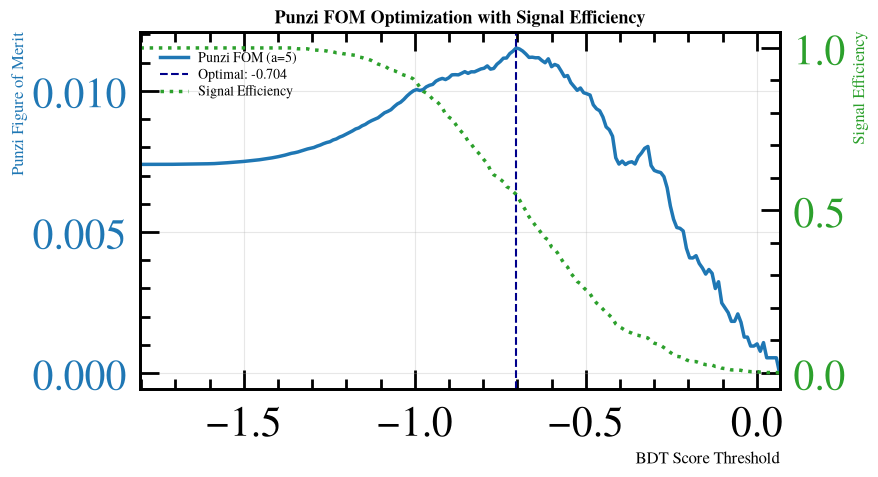

In [12]:
print("="*60)
print("STEP 8: PUNZI OPTIMIZATION")
print("="*60)

# Scan thresholds
thresholds = np.linspace(y_score_test.min(), y_score_test.max(), 200)
signal_efficiency = []
background_efficiency = []
punzi_fom = []

total_signal = np.sum(y_test == 1)
total_background = np.sum(y_test == 0)
a = 5   # Punzi 'a' parameter (target discovery significance)

for t in thresholds:
    passed = y_score_test > t
    S = np.sum(passed & (y_test == 1))
    B = np.sum(passed & (y_test == 0))
    eff_sig = S / total_signal if total_signal > 0 else 0
    eff_bkg = B / total_background if total_background > 0 else 0
    signal_efficiency.append(eff_sig)
    background_efficiency.append(eff_bkg)
    punzi_fom.append(eff_sig / (a/2 + np.sqrt(B)) if B >= 0 else 0)

best_idx = np.argmax(punzi_fom)
best_threshold = thresholds[best_idx]
print(f"Optimal Punzi threshold: {best_threshold:.4f}")
print(f"Signal efficiency at optimum: {signal_efficiency[best_idx]*100:.1f}%")
print(f"Background efficiency at optimum: {background_efficiency[best_idx]*100:.1f}%")

# Plot
fig, ax1 = plt.subplots(figsize=(9, 5))

# Left axis: Punzi FOM
color = 'tab:blue'
ax1.set_xlabel('BDT Score Threshold', fontsize=12)
ax1.set_ylabel('Punzi Figure of Merit', color=color, fontsize=12)
ax1.plot(thresholds, punzi_fom, color=color, linewidth=2.5, label=f'Punzi FOM (a={a})')
ax1.tick_params(axis='y', labelcolor=color)
ax1.axvline(best_threshold, color='darkblue', linestyle='--', linewidth=1.5,
            label=f'Optimal: {best_threshold:.3f}')
ax1.grid(True, alpha=0.3)

# Right axis: Signal efficiency
ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Signal Efficiency', color=color, fontsize=12)
ax2.plot(thresholds, signal_efficiency, color=color, linestyle=':', linewidth=2.5, label='Signal Efficiency')
ax2.tick_params(axis='y', labelcolor=color)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.title('Punzi FOM Optimization with Signal Efficiency', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
print("="*60)
print("STEP 9: SELECTION & MASS EXTRACTION")
print("="*60)

all_scores = bdt.decision_function(X)
df_all.loc[X.index, 'bdt_score'] = all_scores
best_threshold = -0.6
bdt_selection = df_all['bdt_score'] >= best_threshold
selected_data = df_all[bdt_selection]

mass_var = "tagmbc"
n_bins = 40
mass_range = (5.20, 5.30)

selected_mass = selected_data[mass_var].dropna()
counts_sel, bins_sel = np.histogram(selected_mass, bins=n_bins, range=mass_range)
bin_centers = 0.5 * (bins_sel[:-1] + bins_sel[1:])
bin_width = bins_sel[1] - bins_sel[0]

all_mass = df_all[mass_var].dropna()

print(f"Selected events: {len(selected_mass)}")
print(f"Total counts in histogram: {counts_sel.sum()}")

if counts_sel.sum() == 0:
    raise ValueError("No events survive the BDT selection in the fit window - "
                      "loosen best_threshold or check mass_var/mass_range.")

STEP 9: SELECTION & MASS EXTRACTION
Selected events: 4763
Total counts in histogram: 4763


In [14]:
def signal_plus_bkg(x, n_sig, mu, sigma, n_bkg, chi, m0):
    sig_pdf = norm.pdf(x, loc=mu, scale=sigma)
    bkg_pdf = argus.pdf(x, chi, loc=0, scale=m0)
    return n_sig * sig_pdf * bin_width + n_bkg * bkg_pdf * bin_width

total_counts = counts_sel.sum()
p0 = [total_counts*0.2, 5.279, 0.003, total_counts*0.8, 3.0, mass_range[1]]
bounds = (
    [0, mass_range[0], 0.0005, 0, 0.1, mass_range[1] - 0.01],
    [total_counts*2, mass_range[1], 0.02, total_counts*2, 15, mass_range[1] + 0.01]
)

popt, pcov = curve_fit(signal_plus_bkg, bin_centers, counts_sel, p0=p0, bounds=bounds, maxfev=20000)
n_sig_fit, mu_fit, sigma_fit, n_bkg_fit, chi_fit, m0_fit = popt
errs = np.sqrt(np.diag(pcov))
n_sig_err, mu_err, sigma_err, n_bkg_err, chi_err, m0_err = errs
significance = n_sig_fit / n_sig_err if n_sig_err > 0 else float('nan')

print(f"Signal yield  = {n_sig_fit:.1f} +/- {n_sig_err:.1f}")
print(f"Peak (mu)     = {mu_fit:.5f} +/- {mu_err:.5f} GeV")
print(f"Sigma         = {abs(sigma_fit):.5f} +/- {sigma_err:.5f} GeV")
print(f"Background N  = {n_bkg_fit:.1f} +/- {n_bkg_err:.1f}")
print(f"Significance  = {significance:.2f} sigma")

Signal yield  = 250.0 +/- 61.5
Peak (mu)     = 5.27768 +/- 0.00078 GeV
Sigma         = 0.00418 +/- 0.00091 GeV
Background N  = 8260.9 +/- 457.5
Significance  = 4.07 sigma


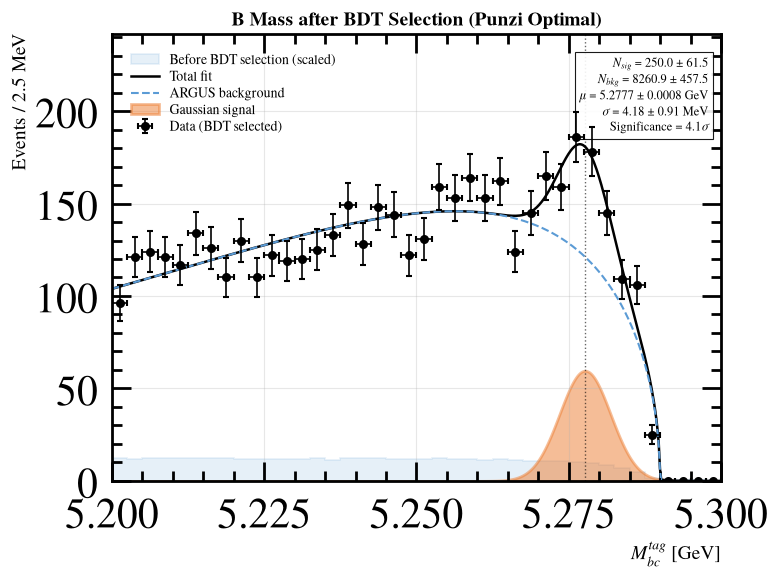

SUMMARY
BDT AUC: 0.826
Optimal Punzi threshold: -0.6000
Signal efficiency: 54.9%
Selected events: 4763
Signal yield: 250.0 +/- 61.5
Significance: 4.1 sigma


In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

scale_all = len(selected_mass) / len(all_mass) if len(all_mass) > 0 else 1
ax.hist(all_mass, bins=bins_sel, histtype='stepfilled',
        color='#5B9BD5', alpha=0.15, edgecolor='#5B9BD5', linewidth=1.2,
        density = 100,
        label='Before BDT selection (scaled)')

x_err = bin_width / 2
ax.errorbar(bin_centers, counts_sel, yerr=np.sqrt(counts_sel + 1e-10), xerr=x_err,
            fmt='o', color='black', markersize=5, elinewidth=1.2, capsize=2,
            label='Data (BDT selected)', zorder=5)

x_fit = np.linspace(mass_range[0], mass_range[1], 500)
sig_curve = n_sig_fit * norm.pdf(x_fit, loc=mu_fit, scale=sigma_fit) * bin_width
bkg_curve = n_bkg_fit * argus.pdf(x_fit, chi_fit, loc=0, scale=m0_fit) * bin_width
total_curve = sig_curve + bkg_curve

ax.plot(x_fit, total_curve, color='black', linewidth=1.8, label='Total fit')
ax.plot(x_fit, bkg_curve, color='#5B9BD5', linewidth=1.5, linestyle='--', label='ARGUS background')
ax.fill_between(x_fit, 0, sig_curve, color='#ED7D31', alpha=0.5, label='Gaussian signal')
ax.axvline(mu_fit, color='black', linestyle=':', linewidth=1.0, alpha=0.6)

ax.set_xlim(mass_range)
ax.set_ylim(0, max(counts_sel.max(), total_curve.max()) * 1.3)
ax.set_xlabel(r'$M_{bc}^{tag}$ [GeV]', fontsize=14)
ax.set_ylabel(f'Events / {bin_width*1000:.1f} MeV', fontsize=14)
ax.set_title('B Mass after BDT Selection (Punzi Optimal)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

stats_text = (
    f'$N_{{sig}}$ = {n_sig_fit:.1f} $\\pm$ {n_sig_err:.1f}\n'
    f'$N_{{bkg}}$ = {n_bkg_fit:.1f} $\\pm$ {n_bkg_err:.1f}\n'
    f'$\\mu$ = {mu_fit:.4f} $\\pm$ {mu_err:.4f} GeV\n'
    f'$\\sigma$ = {sigma_fit*1000:.2f} $\\pm$ {sigma_err*1000:.2f} MeV\n'
    f'Significance = {significance:.1f}$\\sigma$'
)
ax.text(0.98, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='square', facecolor='white', edgecolor='black', linewidth=0.8, alpha=0.9))

plt.tight_layout()
plt.show()

print("="*60)
print("SUMMARY")
print("="*60)
print(f"BDT AUC: {roc_auc:.3f}")
print(f"Optimal Punzi threshold: {best_threshold:.4f}")
print(f"Signal efficiency: {signal_efficiency[best_idx]*100:.1f}%")
print(f"Selected events: {len(selected_data)}")
print(f"Signal yield: {n_sig_fit:.1f} +/- {n_sig_err:.1f}")
print(f"Significance: {significance:.1f} sigma")

Before BDT: N=61206
After BDT:  N=4763


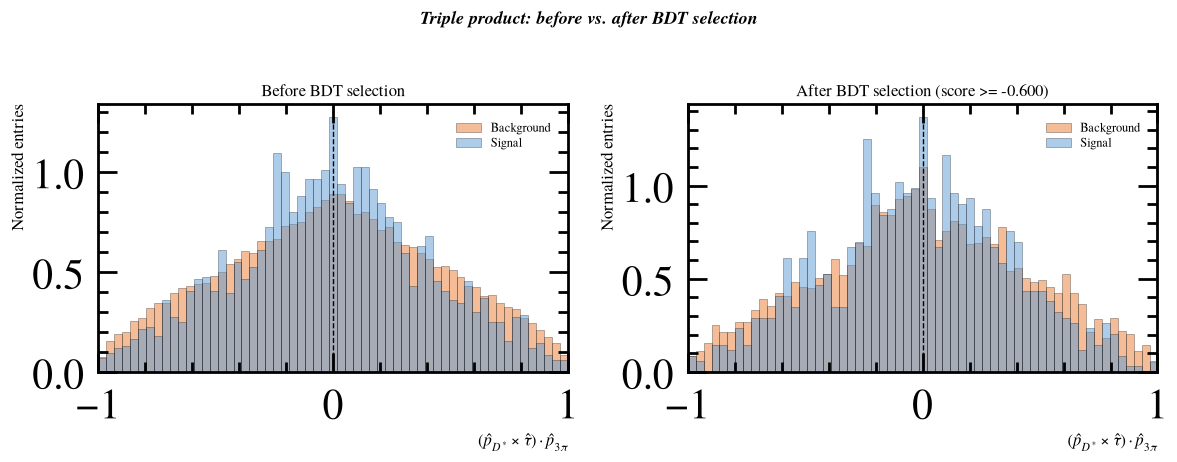

Before BDT, signal       : N=2478, N(+)=1212, N(-)=1266, asymmetry=-0.0218
Before BDT, background   : N=58728, N(+)=29504, N(-)=29224, asymmetry=0.0048
After BDT, signal        : N=1014, N(+)=490, N(-)=524, asymmetry=-0.0335
After BDT, background    : N=3749, N(+)=1843, N(-)=1906, asymmetry=-0.0168


In [17]:
import matplotlib.pyplot as plt
import mplhep as hep

plt.style.use(hep.style.LHCb2)

# =========================================================================
# Triple product: BEFORE vs AFTER BDT selection
# =========================================================================
tp_all = df_all["triple_product_reco"].dropna()
tp_all = tp_all[np.isfinite(tp_all)]

# after BDT selection - using the Punzi-optimal threshold from Block 10
tp_selected = df_all.loc[df_all["bdt_score"] >= best_threshold, "triple_product_reco"].dropna()
tp_selected = tp_selected[np.isfinite(tp_selected)]

print(f"Before BDT: N={len(tp_all)}")
print(f"After BDT:  N={len(tp_selected)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bins = np.linspace(-1, 1, 60)   # bounded [-1,1] since this is now a unit-vector triple product

# --- Panel 1: before BDT selection, split by truth label for context ---
ax = axes[0]
sig_mask_all = df_all.loc[tp_all.index, "label"] == 1
bkg_mask_all = df_all.loc[tp_all.index, "label"] == 0

ax.hist(tp_all[bkg_mask_all], bins=bins, alpha=0.5, color="#ED7D31",
        edgecolor="black", linewidth=0.4, label="Background", density=True)
ax.hist(tp_all[sig_mask_all], bins=bins, alpha=0.5, color="#5B9BD5",
        edgecolor="black", linewidth=0.4, label="Signal", density=True)
ax.axvline(0, color="black", linestyle="--", linewidth=1.0)
ax.set_xlabel(r"$(\hat{p}_{D^*} \times \hat{\tau}) \cdot \hat{p}_{3\pi}$", fontsize=12)
ax.set_ylabel("Normalized entries", fontsize=12)
ax.set_title("Before BDT selection", fontsize=12)
ax.legend(fontsize=9)

# --- Panel 2: after BDT selection, split by truth label ---
ax = axes[1]
sig_mask_sel = df_all.loc[tp_selected.index, "label"] == 1
bkg_mask_sel = df_all.loc[tp_selected.index, "label"] == 0

ax.hist(tp_selected[bkg_mask_sel], bins=bins, alpha=0.5, color="#ED7D31",
        edgecolor="black", linewidth=0.4, label="Background", density=True)
ax.hist(tp_selected[sig_mask_sel], bins=bins, alpha=0.5, color="#5B9BD5",
        edgecolor="black", linewidth=0.4, label="Signal", density=True)
ax.axvline(0, color="black", linestyle="--", linewidth=1.0)
ax.set_xlabel(r"$(\hat{p}_{D^*} \times \hat{\tau}) \cdot \hat{p}_{3\pi}$", fontsize=12)
ax.set_ylabel("Normalized entries", fontsize=12)
ax.set_title(f"After BDT selection (score >= {best_threshold:.3f})", fontsize=12)
ax.legend(fontsize=9)

fig.suptitle("Triple product: before vs. after BDT selection", fontsize=13,
             style="italic", fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

# asymmetry summary, before and after
for label, tp, sig_m, bkg_m in [
    ("Before BDT, signal", tp_all[sig_mask_all], None, None),
    ("Before BDT, background", tp_all[bkg_mask_all], None, None),
    ("After BDT, signal", tp_selected[sig_mask_sel], None, None),
    ("After BDT, background", tp_selected[bkg_mask_sel], None, None),
]:
    n_pos = (tp > 0).sum()
    n_neg = (tp < 0).sum()
    asym = (n_pos - n_neg) / (n_pos + n_neg) if (n_pos + n_neg) > 0 else float('nan')
    print(f"{label:25s}: N={len(tp)}, N(+)={n_pos}, N(-)={n_neg}, asymmetry={asym:.4f}")

# Forward/Backward Tau Asymmetry Analysis

## Definition

The tau polar angle ($\theta_\tau$) is defined relative to the beam axis (z-axis):

$$\cos\theta_{\tau} = \frac{p_z^{\tau}}{|\vec{p}_{\tau}|}$$

where $\vec{p}_{\tau}$ is the tau momentum direction from the interaction point (IP) to the tau decay vertex.

---

## Event Classification

| Region | Condition | Description |
|--------|-----------|-------------|
| **Forward** | $\cos\theta_{\tau} > 0$ | Tau emitted in the forward direction |
| **Backward** | $\cos\theta_{\tau} < 0$ | Tau emitted in the backward direction |

---

## Asymmetries Calculated

### 1. Forward-Backward Asymmetry ($A_{FB}$)

$$A_{FB} = \frac{N_{\text{forward}} - N_{\text{backward}}}{N_{\text{forward}} + N_{\text{backward}}}$$

Measures the imbalance between forward and backward tau emission.

### 2. Triple Product Asymmetry ($A_T$)

$$A_T = \frac{N(\mathcal{T} > 0) - N(\mathcal{T} < 0)}{N(\mathcal{T} > 0) + N(\mathcal{T} < 0)}$$

Calculated separately for:
- Forward events ($A_T^{\text{fwd}}$)
- Backward events ($A_T^{\text{bwd}}$)

---

## Results

| Quantity | Value |
|----------|-------|
| Forward events | $N_{\text{forward}}$ |
| Backward events | $N_{\text{backward}}$ |
| $A_{FB}$ | $A_{FB} \pm \sigma_{A_{FB}}$ |
| $A_T^{\text{fwd}}$ | $A_T^{\text{fwd}} \pm \sigma_{A_T^{\text{fwd}}}$ |
| $A_T^{\text{bwd}}$ | $A_T^{\text{bwd}} \pm \sigma_{A_T^{\text{bwd}}}$ |
| $\Delta A_T$ | $A_T^{\text{fwd}} - A_T^{\text{bwd}}$ |


---

FORWARD/BACKWARD TAU ASYMMETRY
Forward events (cosθ > 0):  1675
Backward events (cosθ < 0): 803
Forward-Backward asymmetry: 0.3519 ± 0.0188

Triple product asymmetry:
  Forward:  A_T = -0.0484 ± 0.0244  (N_plus=797, N_minus=878)
  Backward: A_T = 0.0336 ± 0.0353  (N_plus=415, N_minus=388)


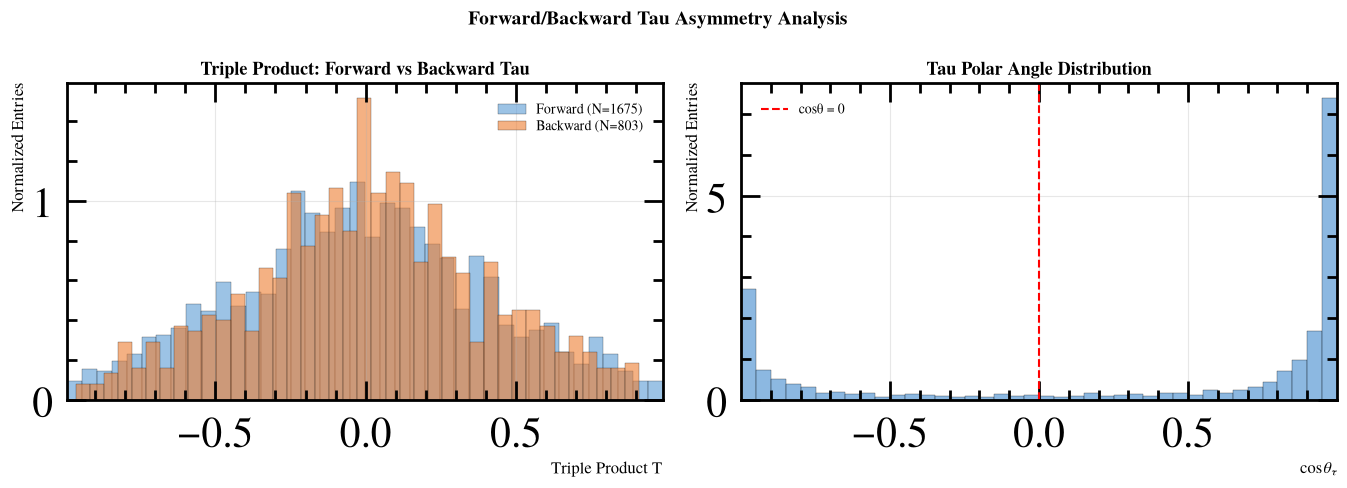


SUMMARY
Total signal events: 2478
Forward events (cosθ > 0):  1675 (67.6%)
Backward events (cosθ < 0): 803 (32.4%)
Forward-Backward asymmetry: 0.3519 ± 0.0188

Triple product asymmetry:
  Forward:  A_T = -0.0484 ± 0.0244
  Backward: A_T = 0.0336 ± 0.0353
  Difference: -0.0820 ± 0.0429


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# FORWARD/BACKWARD TAU ASYMMETRY
# =============================================================================

# Get tau direction (from IP to tau vertex)
tau_dir_x = df_all["taux"] - df_all["IPX"]
tau_dir_y = df_all["tauy"] - df_all["IPY"]
tau_dir_z = df_all["tauz"] - df_all["IPZ"]

# Calculate tau polar angle (cos theta) in lab frame
tau_p = np.sqrt(tau_dir_x**2 + tau_dir_y**2 + tau_dir_z**2)
tau_cos_theta = tau_dir_z / tau_p  # cos(theta) relative to beam axis

# Add to dataframe
df_all["tau_cos_theta"] = tau_cos_theta

# Select signal events
signal_mask = df_all["sigissig"] == 1
signal_df = df_all[signal_mask]

# Forward: cos(theta) > 0
# Backward: cos(theta) < 0
forward_mask = signal_df["tau_cos_theta"] > 0
backward_mask = signal_df["tau_cos_theta"] < 0

# Get triple product for forward and backward
triple_forward = signal_df.loc[forward_mask, "triple_product_reco"].dropna()
triple_backward = signal_df.loc[backward_mask, "triple_product_reco"].dropna()

# Calculate asymmetry for forward events
N_plus_fwd = np.sum(triple_forward > 0)
N_minus_fwd = np.sum(triple_forward < 0)
N_fwd_total = N_plus_fwd + N_minus_fwd
A_T_fwd = (N_plus_fwd - N_minus_fwd) / N_fwd_total if N_fwd_total > 0 else 0
A_T_fwd_err = np.sqrt((1 - A_T_fwd**2) / N_fwd_total) if N_fwd_total > 0 else 0

# Calculate asymmetry for backward events
N_plus_bwd = np.sum(triple_backward > 0)
N_minus_bwd = np.sum(triple_backward < 0)
N_bwd_total = N_plus_bwd + N_minus_bwd
A_T_bwd = (N_plus_bwd - N_minus_bwd) / N_bwd_total if N_bwd_total > 0 else 0
A_T_bwd_err = np.sqrt((1 - A_T_bwd**2) / N_bwd_total) if N_bwd_total > 0 else 0

# Forward-backward asymmetry
N_forward = len(triple_forward)
N_backward = len(triple_backward)
N_total = N_forward + N_backward
A_FB = (N_forward - N_backward) / N_total if N_total > 0 else 0
A_FB_err = np.sqrt((1 - A_FB**2) / N_total) if N_total > 0 else 0

# Difference error propagation (sum in quadrature)
A_T_diff = A_T_fwd - A_T_bwd
A_T_diff_err = np.sqrt(A_T_fwd_err**2 + A_T_bwd_err**2)

print("=" * 60)
print("FORWARD/BACKWARD TAU ASYMMETRY")
print("=" * 60)
print(f"Forward events (cosθ > 0):  {N_forward}")
print(f"Backward events (cosθ < 0): {N_backward}")
print(f"Forward-Backward asymmetry: {A_FB:.4f} ± {A_FB_err:.4f}")
print()
print("Triple product asymmetry:")
print(f"  Forward:  A_T = {A_T_fwd:.4f} ± {A_T_fwd_err:.4f}  (N_plus={N_plus_fwd}, N_minus={N_minus_fwd})")
print(f"  Backward: A_T = {A_T_bwd:.4f} ± {A_T_bwd_err:.4f}  (N_plus={N_plus_bwd}, N_minus={N_minus_bwd})")

# =========================================================================
# PLOT: Triple product for forward vs backward & cos(theta) distribution
# =========================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram comparison
ax = axes[0]
ax.hist(triple_forward, bins=40, density=True, alpha=0.6, color='#5B9BD5', 
        edgecolor='black', linewidth=0.3, label=f'Forward (N={N_forward})')
ax.hist(triple_backward, bins=40, density=True, alpha=0.6, color='#ED7D31', 
        edgecolor='black', linewidth=0.3, label=f'Backward (N={N_backward})')
ax.set_xlabel(r'Triple Product $\mathcal{T}$', fontsize=12)
ax.set_ylabel('Normalized Entries', fontsize=12)
ax.set_title('Triple Product: Forward vs Backward Tau', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Tau cos(theta) distribution
ax = axes[1]
ax.hist(signal_df["tau_cos_theta"].dropna(), bins=40, density=True, alpha=0.7, 
        color='#5B9BD5', edgecolor='black', linewidth=0.3)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='cosθ = 0')
ax.set_xlabel(r'cos$\theta_{\tau}$', fontsize=12)
ax.set_ylabel('Normalized Entries', fontsize=12)
ax.set_title('Tau Polar Angle Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('Forward/Backward Tau Asymmetry Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# =========================================================================
# Print summary
# =========================================================================

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Total signal events: {len(signal_df)}")
print(f"Forward events (cosθ > 0):  {N_forward} ({N_forward/len(signal_df)*100:.1f}%)")
print(f"Backward events (cosθ < 0): {N_backward} ({N_backward/len(signal_df)*100:.1f}%)")
print(f"Forward-Backward asymmetry: {A_FB:.4f} ± {A_FB_err:.4f}")
print()
print("Triple product asymmetry:")
print(f"  Forward:  A_T = {A_T_fwd:.4f} ± {A_T_fwd_err:.4f}")
print(f"  Backward: A_T = {A_T_bwd:.4f} ± {A_T_bwd_err:.4f}")
print(f"  Difference: {A_T_diff:.4f} ± {A_T_diff_err:.4f}")


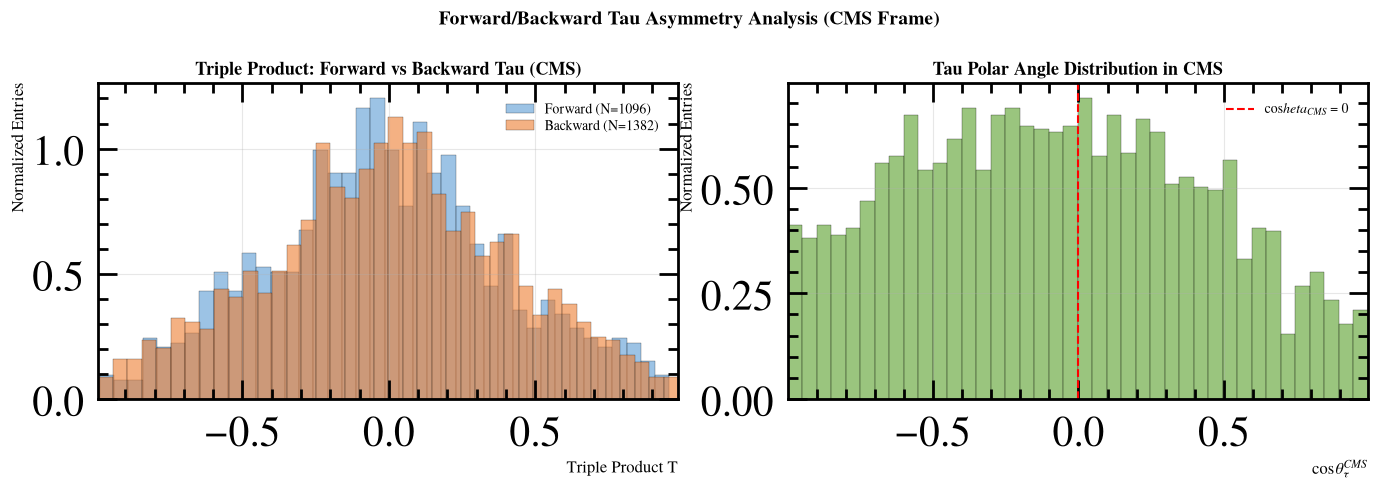

FORWARD/BACKWARD TAU ASYMMETRY (CMS FRAME)
Total signal events: 2478
Forward events (cosθ > 0):  1096 (44.2%)
Backward events (cosθ < 0): 1382 (55.8%)
Forward-Backward asymmetry (A_FB): -0.1154 ± 0.0200

Triple product asymmetry:
  Forward (CMS):  A_T = -0.0584 ± 0.0302
  Backward (CMS): A_T = 0.0072 ± 0.0269
  Difference:       -0.0656 ± 0.0404


In [19]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# FORWARD/BACKWARD TAU ASYMMETRY (CMS NATIVO DE BELLE II)
# =============================================================================

# Extraemos las componentes del momento del tau en el CMS directamente de tus variables
tau_px_cms = df_all["taupxcms"]
tau_py_cms = df_all["taupycms"]
tau_pz_cms = df_all["taupzcms"]

# Calculamos la magnitud del momento en el CMS
tau_p_cms = np.sqrt(tau_px_cms**2 + tau_py_cms**2 + tau_pz_cms**2)

# Calculamos el cos(theta) en el CMS (eje z relativo al haz en el CMS)
df_all["tau_cos_theta_CMS"] = tau_pz_cms / tau_p_cms

# Seleccionar eventos de señal usando tu máscara original
signal_mask = df_all["sigissig"] == 1
signal_df = df_all[signal_mask]

# Clasificación Forward / Backward con el ángulo físico en el CMS
forward_mask = signal_df["tau_cos_theta_CMS"] > 0
backward_mask = signal_df["tau_cos_theta_CMS"] < 0

# Obtener producto triple para cada hemisferio
triple_forward = signal_df.loc[forward_mask, "triple_product_reco"].dropna()
triple_backward = signal_df.loc[backward_mask, "triple_product_reco"].dropna()

# Cálculos estadísticos y errores binomiales para Forward
N_plus_fwd = np.sum(triple_forward > 0)
N_minus_fwd = np.sum(triple_forward < 0)
N_fwd_total = N_plus_fwd + N_minus_fwd
A_T_fwd = (N_plus_fwd - N_minus_fwd) / N_fwd_total if N_fwd_total > 0 else 0
A_T_fwd_err = np.sqrt((1 - A_T_fwd**2) / N_fwd_total) if N_fwd_total > 0 else 0

# Cálculos estadísticos y errores binomiales para Backward
N_plus_bwd = np.sum(triple_backward > 0)
N_minus_bwd = np.sum(triple_backward < 0)
N_bwd_total = N_plus_bwd + N_minus_bwd
A_T_bwd = (N_plus_bwd - N_minus_bwd) / N_bwd_total if N_bwd_total > 0 else 0
A_T_bwd_err = np.sqrt((1 - A_T_bwd**2) / N_bwd_total) if N_bwd_total > 0 else 0

# Asimetría Forward-Backward real en el CMS
N_forward = len(triple_forward)
N_backward = len(triple_backward)
N_total = N_forward + N_backward
A_FB = (N_forward - N_backward) / N_total if N_total > 0 else 0
A_FB_err = np.sqrt((1 - A_FB**2) / N_total) if N_total > 0 else 0

# Propagación de error de la diferencia de asimetrías
A_T_diff = A_T_fwd - A_T_bwd
A_T_diff_err = np.sqrt(A_T_fwd_err**2 + A_T_bwd_err**2)

# =========================================================================
# PLOT COMPARATIVO (CMS NATIVO)
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma del Producto Triple
ax = axes[0]
ax.hist(triple_forward, bins=40, density=True, alpha=0.6, color='#5B9BD5', 
        edgecolor='black', linewidth=0.3, label=f'Forward (N={N_forward})')
ax.hist(triple_backward, bins=40, density=True, alpha=0.6, color='#ED7D31', 
        edgecolor='black', linewidth=0.3, label=f'Backward (N={N_backward})')
ax.set_xlabel(r'Triple Product $\mathcal{T}$', fontsize=12)
ax.set_ylabel('Normalized Entries', fontsize=12)
ax.set_title('Triple Product: Forward vs Backward Tau (CMS)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Histograma de cos(theta) en el CMS
ax = axes[1]
ax.hist(signal_df["tau_cos_theta_CMS"].dropna(), bins=40, density=True, alpha=0.7, 
        color='#70AD47', edgecolor='black', linewidth=0.3)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='cos$\theta_{CMS}$ = 0')
ax.set_xlabel(r'cos$\theta_{\tau}^{CMS}$', fontsize=12)
ax.set_ylabel('Normalized Entries', fontsize=12)
ax.set_title('Tau Polar Angle Distribution in CMS', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('Forward/Backward Tau Asymmetry Analysis (CMS Frame)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# =========================================================================
# IMPRESIÓN DE RESULTADOS (CMS)
# =========================================================================
print("=" * 60)
print("FORWARD/BACKWARD TAU ASYMMETRY (CMS FRAME)")
print("=" * 60)
print(f"Total signal events: {len(signal_df)}")
print(f"Forward events (cosθ > 0):  {N_forward} ({N_forward/len(signal_df)*100:.1f}%)")
print(f"Backward events (cosθ < 0): {N_backward} ({N_backward/len(signal_df)*100:.1f}%)")
print(f"Forward-Backward asymmetry (A_FB): {A_FB:.4f} ± {A_FB_err:.4f}")
print()
print("Triple product asymmetry:")
print(f"  Forward (CMS):  A_T = {A_T_fwd:.4f} ± {A_T_fwd_err:.4f}")
print(f"  Backward (CMS): A_T = {A_T_bwd:.4f} ± {A_T_bwd_err:.4f}")
print(f"  Difference:       {A_T_diff:.4f} ± {A_T_diff_err:.4f}")
